# TN3K Radiomics -> LLM Classification (Ra et al. pipeline), end-to-end

Single reproducible notebook implementing the pipeline of Ra et al. (2025),
*"Enhancing radiomics features via a large language model for classifying benign and malignant
tumors"*, applied to the TN3K thyroid ultrasound dataset.

The notebook runs end to end from the TN3K ground-truth masks:

- **Part A - Data preparation:** manifest and QC, disjoint train/validation/calibration/test
  splits, PyRadiomics feature extraction, train-only standardization, mRMR selection of 8
  features, and construction of the feature-name + value input prompts.
- **Part B - LLM classification:** an LLM backbone with a linear classification head, adapted
  with LoRA and fine-tuned to predict benign vs. malignant, evaluated on the internal test set.
- **Part C - Baselines and comparison:** classical ML models (RF, SVM, LR) on the same 8
  standardized features, reported alongside the LLM results.
- **Part D - Conformal triage:** the fine-tuned model is queried with perturbed prompts; the
  vote count drives a three-way rule (auto-benign / auto-malignant / refer) whose thresholds
  are calibrated with Learn-then-Test on the calibration split, compared against classic and
  Mondrian split CP.

Reproducibility: fixed seed (42), train-only fitting of imputer/scaler/mRMR, and explicit
leakage checks. The calibration split is used only by Part D.

## 0. Configuration

In [ ]:
# ----------------------------------------------------------------------------
# Data source: choose how the TN3K dataset is accessed.
#   "drive" -> mount Google Drive (Colab)
#   "local" -> read from a local directory (no Drive)
#   "drive" -> mount Google Drive (Colab)
#   "local" -> read from a local directory
#   "repo"  -> running from a cloned repo that ships the cached radiomics CSVs (no Drive)
DATA_SOURCE = "drive"                 # "drive", "local", or "repo"
LOCAL_TN3K_ROOT = "/content/tn3k"     # used only when DATA_SOURCE == "local"

# Cache: if a stage's output files already exist (e.g. uploaded to the repo), reuse them
# instead of recomputing. Set USE_CACHE=False to force everything to re-run from scratch.
USE_CACHE = True

# Stage switches (kept for manual control; normally leave as-is and rely on USE_CACHE)
RUN_RADIOMICS_EXTRACTION = True
RUN_FEATURE_SELECTION = True
RUN_LLM = True

# Reproducibility
SEED = 42

# Radiomics
RADIOMICS_BIN_WIDTH = 25
NORMALIZE_EACH_IMAGE_TO_UINT8 = True
MIN_MASK_PIXELS = 20
N_SELECTED_FEATURES = 8

# Splits (applied to the official trainval; official test is kept untouched)
TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
CALIBRATION_FRACTION = 0.15

# LLM / LoRA (small model + 4-bit QLoRA so the pipeline runs on a free T4)
MODEL_NAME   = "Qwen/Qwen2.5-1.5B"
MODEL_SHORT  = "qwen15b"
LOAD_IN_4BIT = True
MAX_LENGTH   = 256
LR           = 2e-4
NUM_EPOCHS   = 5
TRAIN_BATCH  = 8
EVAL_BATCH   = 16
GRAD_ACCUM   = 2
LORA_R       = 16
LORA_ALPHA   = 32
LORA_DROPOUT = 0.05
RUN_TAG      = f"seed{SEED}_{MODEL_SHORT}"

# Constants used by both data-prep and cache paths (kept here so they are always defined)
LABEL_NAMES = {0: "benign", 1: "malignant"}
VALID_IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

# Part A - Data preparation

## A0. Install dependencies

In [ ]:
# Dependencies.
#   - Light packages (incl. SimpleITK, mrmr-selection) are always installed.
#   - pyradiomics is the ONLY heavy/build-fragile one; it is installed only when we actually
#     need to extract features from images (no cached radiomics_*.csv found). This avoids its
#     build error on recent Python in Colab while still keeping mRMR available.
import sys, subprocess
from pathlib import Path as _P

def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

def _cache_csvs_present():
    splits = ["train", "validation", "calibration", "test"]
    dirs = [_P.cwd() / "features", _P("/content/features")]
    dirs += list(_P("/content").glob("*/features"))
    dirs += list(_P.cwd().glob("**/features"))
    return any(d.exists() and all((d / f"radiomics_{s}.csv").exists() for s in splits) for d in dirs)

_NEED_PYRADIOMICS = not _cache_csvs_present()

# Always installed. Pin the LLM stack to a mutually compatible set: a peft version that ships
# `velora_config` together with a transformers/bitsandbytes that expect it. (Mismatched versions
# cause: AttributeError: \'LoraConfig\' object has no attribute \'velora_config\'.)
# Minimal, targeted fix. Colab already ships mutually-compatible transformers/peft/accelerate;
# the failures came from bitsandbytes being out of step with the runtime's PyTorch/triton:
#   - too old  -> "No module named 'triton.ops'"
#   - mismatched with peft -> "LoraConfig has no attribute velora_config"
# Pinning bitsandbytes to a known-good version that matches recent PyTorch/triton fixes both.
# We deliberately do NOT force transformers/peft versions, to stay compatible with Colab's stack.
_pip("transformers", "peft", "accelerate", "datasets")   # ensure present (no version pins)
_pip("bitsandbytes>=0.46.1")   # >=0.46.1 required by current transformers for 4-bit
_pip("scikit-learn", "pandas", "numpy", "joblib", "opencv-python-headless")
_pip("SimpleITK", "mrmr-selection")

# pyradiomics only when extraction is actually required
if _NEED_PYRADIOMICS:
    print("No cached radiomics CSVs found -> installing pyradiomics for feature extraction...")
    _pip("pyradiomics")
else:
    print("Cached radiomics CSVs found -> skipping pyradiomics (extraction not needed).")

print("\n" + "=" * 70)
print("If package versions changed, RESTART THE RUNTIME now")
print("(Runtime -> Restart runtime), then run all cells again.")
print("=" * 70)

## A1. Imports, reproducibility, and data source

In [ ]:
import json, math, re, warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
try:
    import cv2
except Exception:
    cv2 = None

from IPython.display import display
from scipy import ndimage as ndi
from sklearn.impute import SimpleImputer
from sklearn.metrics import (average_precision_score, balanced_accuracy_score,
                             classification_report, roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# mRMR is lightweight and always available.
from mrmr import mrmr_classif

# pyradiomics/SimpleITK are only needed for extraction from images; import lazily.
try:
    import SimpleITK as sitk
    from radiomics import featureextractor
    _RADIOMICS_IMPORTS_OK = True
except Exception as _e:
    sitk = featureextractor = None
    _RADIOMICS_IMPORTS_OK = False
    print("pyradiomics/SimpleITK not imported (fine if using cached CSVs):", _e)

np.random.seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)

# Resolve the dataset root according to DATA_SOURCE.
if DATA_SOURCE == "drive":
    from google.colab import drive
    drive.mount("/content/drive")
    THESIS_ROOT = Path("/content/drive/MyDrive/thesis_baseline")
    TN3K_ROOT = THESIS_ROOT / "tn3k"
elif DATA_SOURCE == "local":
    TN3K_ROOT = Path(LOCAL_TN3K_ROOT)
    THESIS_ROOT = TN3K_ROOT.parent
elif DATA_SOURCE == "repo":
    # Running from a cloned repo that ships the cached CSVs (no Drive, images optional).
    THESIS_ROOT = Path.cwd()
    TN3K_ROOT = THESIS_ROOT / "tn3k"
else:
    raise ValueError("DATA_SOURCE must be 'drive', 'local', or 'repo'.")
print("TN3K root:", TN3K_ROOT)

## A2. Paths

In [ ]:

TRAINVAL_IMAGE_DIR = TN3K_ROOT / "trainval-image"
TRAINVAL_MASK_DIR = TN3K_ROOT / "trainval-mask"
TEST_IMAGE_DIR = TN3K_ROOT / "test-image"
TEST_MASK_DIR = TN3K_ROOT / "test-mask"

TRAINVAL_LABELS_PATH = TN3K_ROOT / "label4trainval.csv"
TEST_LABELS_PATH = TN3K_ROOT / "label4test.csv"

OUTPUT_ROOT = THESIS_ROOT / "tn3k_gt_radiomics"
MANIFEST_DIR = OUTPUT_ROOT / "manifests"
QC_DIR = OUTPUT_ROOT / "qc"
FEATURES_DIR = OUTPUT_ROOT / "features"
ARTIFACTS_DIR = OUTPUT_ROOT / "artifacts"
PROMPTS_DIR = OUTPUT_ROOT / "prompts"

for folder in [OUTPUT_ROOT, MANIFEST_DIR, QC_DIR, FEATURES_DIR, ARTIFACTS_DIR, PROMPTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

required_paths = [
    TRAINVAL_IMAGE_DIR, TRAINVAL_MASK_DIR, TEST_IMAGE_DIR, TEST_MASK_DIR,
    TRAINVAL_LABELS_PATH, TEST_LABELS_PATH,
]
IMAGES_AVAILABLE = all(path.exists() for path in required_paths)
for path in required_paths:
    print(f"{'OK' if path.exists() else 'MISSING':8} {path}")
print("\nImages available:", IMAGES_AVAILABLE)
print("Outputs will be written to:", OUTPUT_ROOT)

In [ ]:
# ----------------------------------------------------------------------------
# Cache mode: if the four radiomics_{split}.csv files already exist and USE_CACHE is on,
# the whole image-dependent block (manifest, QC, split, PyRadiomics extraction) is skipped,
# and downstream stages read straight from the cached CSVs. This lets the notebook run
# WITHOUT the TN3K images (e.g. from a clone that only has the committed CSVs).
SPLIT_NAMES = ["train", "validation", "calibration", "test"]

# Look for the cached radiomics CSVs in a few likely locations, so the notebook works whether
# they live under OUTPUT_ROOT (a full local/Drive run) or in a `features/` folder at the repo
# root (e.g. after `git clone` into /content/<repo>). The first location that has all four
# CSVs becomes FEATURES_DIR.
def _has_all_radiomics(folder):
    return folder.exists() and all((folder / f"radiomics_{s}.csv").exists() for s in SPLIT_NAMES)

_cwd = Path.cwd()
_candidate_feature_dirs = [
    FEATURES_DIR,                     # standard OUTPUT_ROOT/features
    _cwd / "features",               # repo root when notebook is run from the repo
    Path("/content") / "features",   # csvs uploaded straight to /content/features
]
# also scan one level down from /content for a cloned repo that contains features/
for _p in Path("/content").glob("*/features"):
    _candidate_feature_dirs.append(_p)

_found = next((d for d in _candidate_feature_dirs if _has_all_radiomics(d)), None)
if USE_CACHE and _found is not None:
    FEATURES_DIR = _found
    print("Found cached radiomics CSVs in:", FEATURES_DIR)

CACHE_MODE = USE_CACHE and _has_all_radiomics(FEATURES_DIR)

if CACHE_MODE:
    print("CACHE_MODE = True -> using cached radiomics CSVs; image-dependent steps are skipped.")
    # Reconstruct split_frames and radiomics_tables directly from the cached CSVs.
    radiomics_tables = {s: pd.read_csv(FEATURES_DIR / f"radiomics_{s}.csv") for s in SPLIT_NAMES}
    split_frames = {}
    for s, tbl in radiomics_tables.items():
        keep = [c for c in ["id", "image_name", "official_split", "analysis_split",
                             "label", "label_name"] if c in tbl.columns]
        fr = tbl[keep].copy()
        fr["analysis_split"] = s
        if "id" in fr.columns and "official_split" in fr.columns:
            fr["sample_id"] = fr["official_split"].astype(str) + "/" + fr["id"].astype(str)
        split_frames[s] = fr.reset_index(drop=True)
else:
    print("CACHE_MODE = False -> running full pipeline from images "
          "(requires TN3K images/masks to be available).")

# Guard: if we are NOT in cache mode and images are also missing, stop with a clear message.
if not CACHE_MODE and not IMAGES_AVAILABLE:
    raise FileNotFoundError(
        "Neither cached radiomics CSVs nor the TN3K images were found.\n"
        "Provide ONE of:\n"
        "  (a) features/radiomics_{train,validation,calibration,test}.csv  (cache mode), or\n"
        "  (b) the TN3K images/masks under TN3K_ROOT (full pipeline).\n"
        f"Looked for CSVs in: {[str(d) for d in _candidate_feature_dirs]}")

## A3. Image-mask-label manifest

In [4]:
if not CACHE_MODE:
    

    def read_headerless_labels(path: Path) -> pd.DataFrame:
        labels = pd.read_csv(
            path,
            header=None,
            names=["image_name", "label"],
            dtype={"image_name": str},
        )

        labels["image_name"] = labels["image_name"].str.strip()
        labels["id"] = labels["image_name"].map(lambda x: Path(x).stem)
        labels["label"] = pd.to_numeric(labels["label"], errors="raise").astype(int)

        if labels["id"].duplicated().any():
            duplicated = labels.loc[labels["id"].duplicated(keep=False), "id"].tolist()
            raise ValueError(f"Duplicate label IDs found: {duplicated[:10]}")

        unknown = sorted(set(labels["label"]) - set(LABEL_NAMES))
        if unknown:
            raise ValueError(f"Unexpected label values: {unknown}")

        labels["label_name"] = labels["label"].map(LABEL_NAMES)
        return labels


    def build_path_map(folder: Path) -> dict[str, Path]:
        paths = [
            path for path in folder.iterdir()
            if path.is_file() and path.suffix.lower() in VALID_IMAGE_EXTENSIONS
        ]

        result = {}
        duplicates = []

        for path in paths:
            if path.stem in result:
                duplicates.append(path.stem)
            result[path.stem] = path

        if duplicates:
            raise ValueError(
                f"Multiple files share the same stem in {folder}: {duplicates[:10]}"
            )

        return result


    def build_manifest(
        official_split: str,
        image_dir: Path,
        mask_dir: Path,
        labels_path: Path,
    ) -> pd.DataFrame:
        labels = read_headerless_labels(labels_path)
        images = build_path_map(image_dir)
        masks = build_path_map(mask_dir)

        image_ids = set(images)
        mask_ids = set(masks)
        label_ids = set(labels["id"])

        diagnostics = {
            "images": len(image_ids),
            "masks": len(mask_ids),
            "labels": len(label_ids),
            "images_without_masks": len(image_ids - mask_ids),
            "masks_without_images": len(mask_ids - image_ids),
            "images_without_labels": len(image_ids - label_ids),
            "labels_without_images": len(label_ids - image_ids),
        }

        print(f"\n{official_split.upper()} integrity check")
        display(pd.Series(diagnostics, name="count").to_frame())

        if any(diagnostics[key] for key in [
            "images_without_masks",
            "masks_without_images",
            "images_without_labels",
            "labels_without_images",
        ]):
            raise ValueError(f"{official_split}: image, mask, and label IDs do not match.")

        rows = []
        indexed_labels = labels.set_index("id")

        for image_id in sorted(image_ids):
            label_row = indexed_labels.loc[image_id]
            rows.append({
                "id": image_id,
                "image_name": images[image_id].name,
                "official_split": official_split,
                "label": int(label_row["label"]),
                "label_name": label_row["label_name"],
                "image_path": str(images[image_id]),
                "mask_path": str(masks[image_id]),
            })

        return pd.DataFrame(rows)


    trainval_manifest = build_manifest(
        official_split="trainval",
        image_dir=TRAINVAL_IMAGE_DIR,
        mask_dir=TRAINVAL_MASK_DIR,
        labels_path=TRAINVAL_LABELS_PATH,
    )

    test_manifest = build_manifest(
        official_split="test",
        image_dir=TEST_IMAGE_DIR,
        mask_dir=TEST_MASK_DIR,
        labels_path=TEST_LABELS_PATH,
    )

    official_manifest = pd.concat(
        [trainval_manifest, test_manifest],
        ignore_index=True,
    )

    official_manifest.to_csv(
        MANIFEST_DIR / "tn3k_official_manifest.csv",
        index=False,
    )

    print("\nOfficial manifest shape:", official_manifest.shape)
    display(official_manifest.head())


TRAINVAL integrity check


,count
images,2879
masks,2879
labels,2879
images_without_masks,0
masks_without_images,0
images_without_labels,0
labels_without_images,0



TEST integrity check


,count
images,614
masks,614
labels,614
images_without_masks,0
masks_without_images,0
images_without_labels,0
labels_without_images,0



Official manifest shape: (3493, 7)


,id,image_name,official_split,label,label_name,image_path,mask_path
0,0000,0000.jpg,trainval,0,benign,/content/drive/MyDrive/thesis_baseline/tn3k/tr...,/content/drive/MyDrive/thesis_baseline/tn3k/tr...
1,0001,0001.jpg,trainval,0,benign,/content/drive/MyDrive/thesis_baseline/tn3k/tr...,/content/drive/MyDrive/thesis_baseline/tn3k/tr...
2,0002,0002.jpg,trainval,0,benign,/content/drive/MyDrive/thesis_baseline/tn3k/tr...,/content/drive/MyDrive/thesis_baseline/tn3k/tr...
3,0003,0003.jpg,trainval,0,benign,/content/drive/MyDrive/thesis_baseline/tn3k/tr...,/content/drive/MyDrive/thesis_baseline/tn3k/tr...
4,0004,0004.jpg,trainval,0,benign,/content/drive/MyDrive/thesis_baseline/tn3k/tr...,/content/drive/MyDrive/thesis_baseline/tn3k/tr...


## A4. Dataset summary

In [5]:
if not CACHE_MODE:
    summary = (
        official_manifest
        .groupby(["official_split", "label", "label_name"])
        .size()
        .rename("n")
        .reset_index()
    )

    display(summary)

    print("Total cases:", len(official_manifest))
    print("Trainval cases:", len(trainval_manifest))
    print("Test cases:", len(test_manifest))

,official_split,label,label_name,n
0,test,0,benign,378
1,test,1,malignant,236
2,trainval,0,benign,1905
3,trainval,1,malignant,974


Total cases: 3493
Trainval cases: 2879
Test cases: 614


## A5. Ground-truth mask sanity check

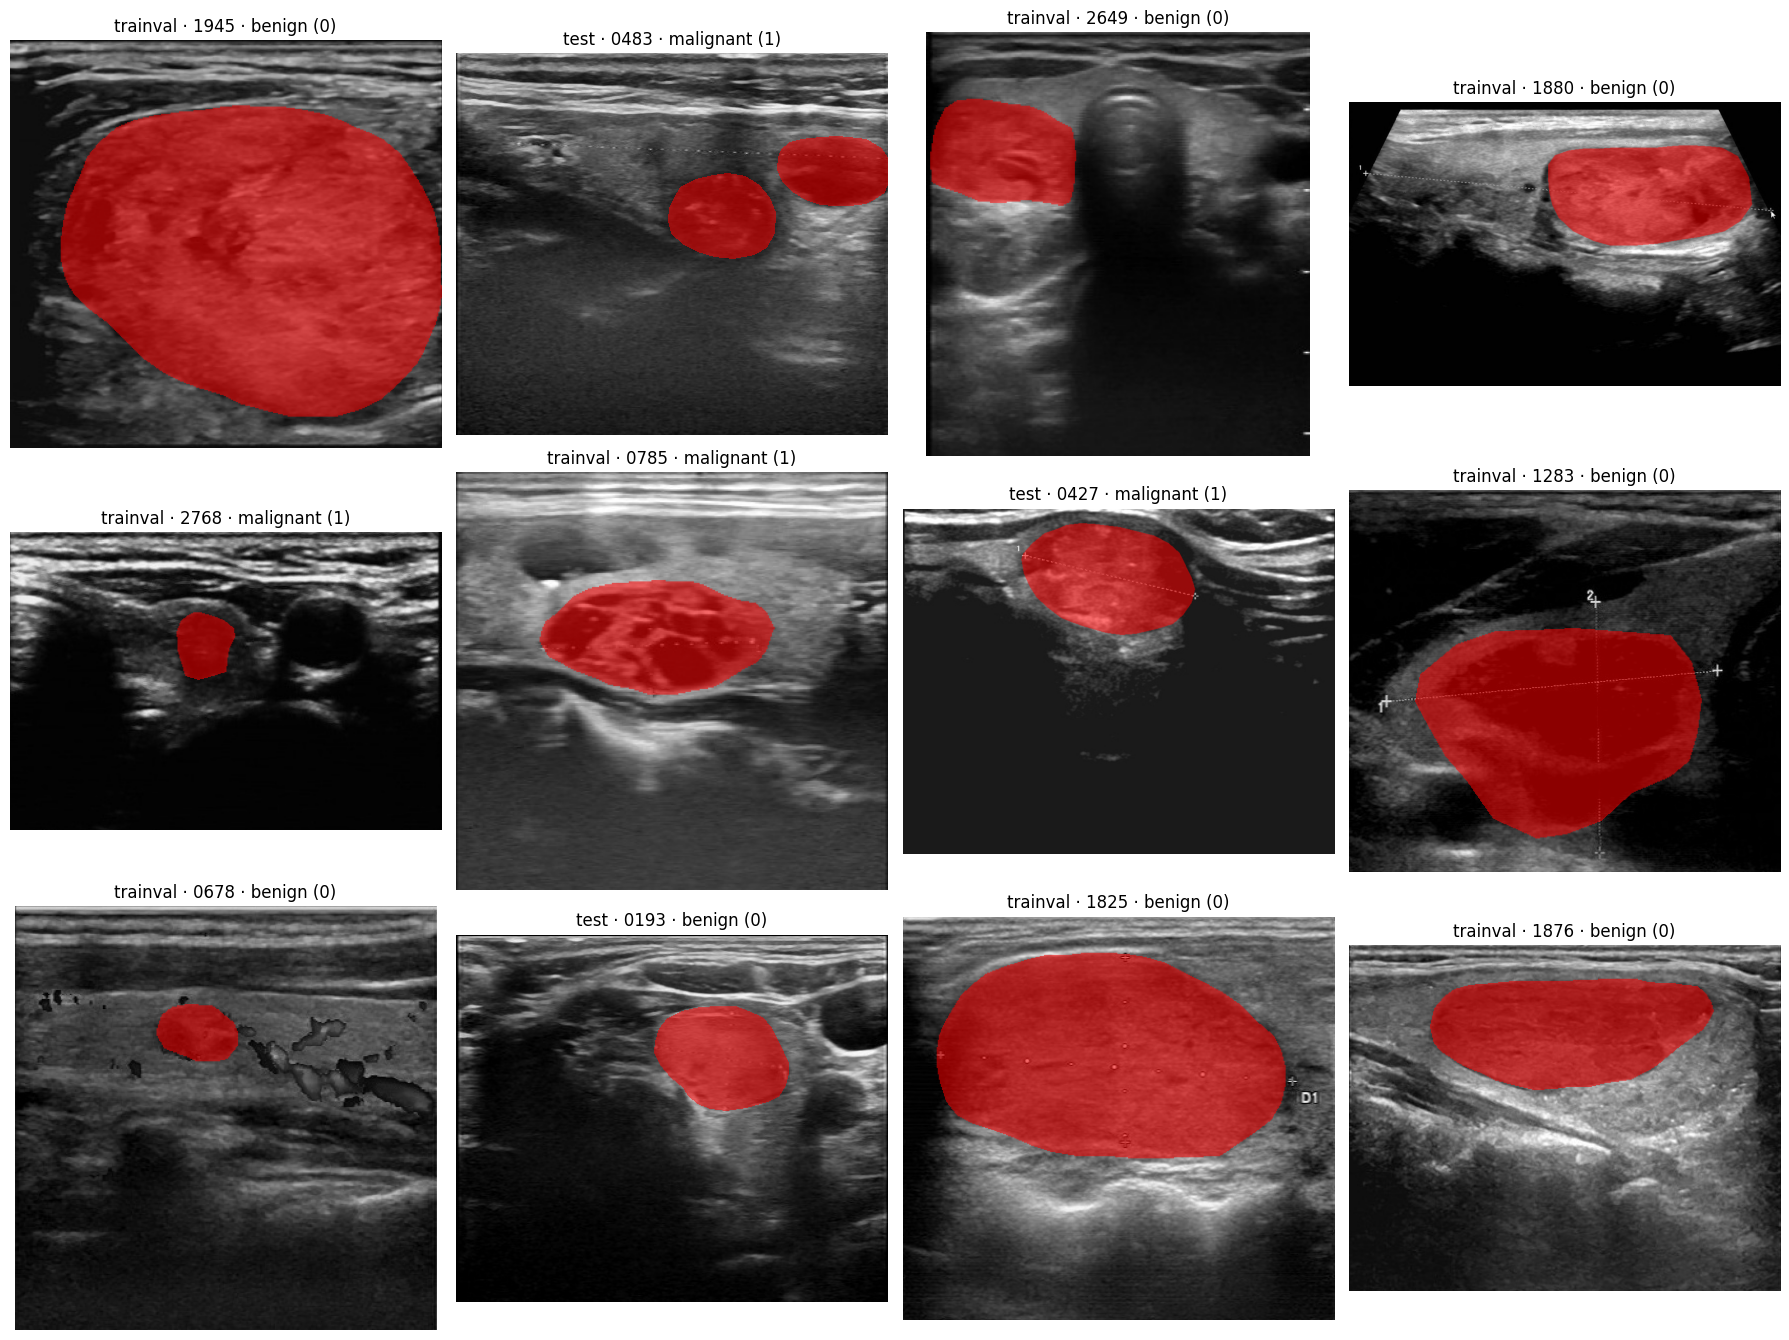

In [6]:
if not CACHE_MODE:
    def load_image_rgb(path: str | Path) -> np.ndarray:
        image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
        if image_bgr is None:
            raise FileNotFoundError(path)
        return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


    def load_binary_mask(path: str | Path, threshold: int = 127) -> np.ndarray:
        mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise FileNotFoundError(path)
        return mask > threshold


    def show_gt_overlays(
        manifest: pd.DataFrame,
        n: int = 12,
        seed: int = SEED,
        cols: int = 4,
    ):
        sample = manifest.sample(min(n, len(manifest)), random_state=seed)
        rows = math.ceil(len(sample) / cols)

        fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 4.5 * rows))
        axes = np.atleast_1d(axes).ravel()

        for ax, (_, row) in zip(axes, sample.iterrows()):
            image = load_image_rgb(row["image_path"])
            mask = load_binary_mask(row["mask_path"])

            if image.shape[:2] != mask.shape:
                raise ValueError(
                    f"Shape mismatch for {row['id']}: "
                    f"image={image.shape[:2]}, mask={mask.shape}"
                )

            overlay = image.copy()
            overlay[mask] = (
                0.45 * overlay[mask] + 0.55 * np.array([255, 0, 0])
            ).astype(np.uint8)

            ax.imshow(overlay)
            ax.set_title(
                f"{row['official_split']} · {row['id']} · "
                f"{row['label_name']} ({row['label']})"
            )
            ax.axis("off")

        for ax in axes[len(sample):]:
            ax.axis("off")

        plt.tight_layout()


    show_gt_overlays(official_manifest, n=12)

## A6. Mask integrity checks

In [7]:
if not CACHE_MODE:
    RUN_MASK_QC = True


    def inspect_gt_mask(row: pd.Series) -> dict:
        image = cv2.imread(str(row["image_path"]), cv2.IMREAD_GRAYSCALE)
        raw_mask = cv2.imread(str(row["mask_path"]), cv2.IMREAD_GRAYSCALE)

        if image is None:
            return {"qc_status": "image_unreadable"}
        if raw_mask is None:
            return {"qc_status": "mask_unreadable"}

        mask = raw_mask > 127
        same_shape = image.shape == mask.shape
        mask_pixels = int(mask.sum())
        image_pixels = int(mask.size)

        if same_shape:
            _, n_components = ndi.label(mask)
            touches_border = bool(
                mask[0, :].any()
                or mask[-1, :].any()
                or mask[:, 0].any()
                or mask[:, -1].any()
            )
        else:
            n_components = np.nan
            touches_border = np.nan

        if not same_shape:
            status = "shape_mismatch"
        elif mask_pixels == 0:
            status = "empty"
        elif mask_pixels < MIN_MASK_PIXELS:
            status = "too_small"
        else:
            status = "ok"

        return {
            "qc_status": status,
            "image_height": int(image.shape[0]),
            "image_width": int(image.shape[1]),
            "mask_height": int(mask.shape[0]),
            "mask_width": int(mask.shape[1]),
            "same_shape": bool(same_shape),
            "mask_pixels": mask_pixels,
            "mask_fraction": mask_pixels / image_pixels,
            "n_components": n_components,
            "touches_border": touches_border,
            "raw_mask_min": int(raw_mask.min()),
            "raw_mask_max": int(raw_mask.max()),
            "raw_mask_unique_count": int(np.unique(raw_mask).size),
        }


    if RUN_MASK_QC:
        qc_rows = []

        for index, row in official_manifest.iterrows():
            qc_rows.append({
                **row.to_dict(),
                **inspect_gt_mask(row),
            })

            if (index + 1) % 250 == 0:
                print(f"Checked {index + 1}/{len(official_manifest)}")

        gt_mask_qc = pd.DataFrame(qc_rows)
        gt_mask_qc.to_csv(QC_DIR / "tn3k_gt_mask_qc.csv", index=False)

        print("\nQC status:")
        display(gt_mask_qc["qc_status"].value_counts(dropna=False).to_frame("n"))

        print("\nAdditional review flags:")
        display(pd.Series({
            "multiple_components": int((gt_mask_qc["n_components"] > 1).sum()),
            "touches_border": int((gt_mask_qc["touches_border"] == True).sum()),
            "very_small_mask_fraction_<0.001": int(
                (gt_mask_qc["mask_fraction"] < 0.001).sum()
            ),
        }, name="n").to_frame())

        print("Saved:", QC_DIR / "tn3k_gt_mask_qc.csv")

Checked 250/3493
Checked 500/3493
Checked 750/3493
Checked 1000/3493
Checked 1250/3493
Checked 1500/3493
Checked 1750/3493
Checked 2000/3493
Checked 2250/3493
Checked 2500/3493
Checked 2750/3493
Checked 3000/3493
Checked 3250/3493

QC status:


,n
qc_status,
ok,3493



Additional review flags:


,n
multiple_components,298
touches_border,356
very_small_mask_fraction_<0.001,0


Saved: /content/drive/MyDrive/thesis_baseline/tn3k_gt_radiomics/qc/tn3k_gt_mask_qc.csv


In [8]:
if not CACHE_MODE:
    def show_qc_cases(
        qc_table: pd.DataFrame,
        query: str = 'qc_status != "ok"',
        n: int = 12,
        seed: int = SEED,
    ):
        subset = qc_table.query(query).copy()

        if subset.empty:
            print("No cases matched:", query)
            return

        show_gt_overlays(
            subset,
            n=min(n, len(subset)),
            seed=seed,
        )


    if RUN_MASK_QC:
        # Technical failures, if any.
        show_qc_cases(gt_mask_qc, query='qc_status != "ok"', n=12)

        # Optional review of masks with multiple connected components.
        # show_qc_cases(gt_mask_qc, query="n_components > 1", n=12)

No cases matched: qc_status != "ok"


## A7. Disjoint splits (official test kept untouched)

In [ ]:
if not CACHE_MODE:

    assert np.isclose(
        TRAIN_FRACTION + VALIDATION_FRACTION + CALIBRATION_FRACTION,
        1.0,
    )

    # ---------------------------------------------------------
    # 1. Build globally unique sample_id
    # ---------------------------------------------------------

    trainval_manifest = trainval_manifest.copy()
    test_manifest = test_manifest.copy()

    trainval_manifest["source_split"] = "trainval"
    test_manifest["source_split"] = "test"

    trainval_manifest["sample_id"] = (
        trainval_manifest["source_split"].astype(str)
        + "/"
        + trainval_manifest["id"].astype(str)
    )

    test_manifest["sample_id"] = (
        test_manifest["source_split"].astype(str)
        + "/"
        + test_manifest["id"].astype(str)
    )

    assert trainval_manifest["sample_id"].is_unique
    assert test_manifest["sample_id"].is_unique

    # ---------------------------------------------------------
    # 2. Split trainval into train / validation / calibration
    # ---------------------------------------------------------

    development_train, development_temp = train_test_split(
        trainval_manifest,
        test_size=VALIDATION_FRACTION + CALIBRATION_FRACTION,
        stratify=trainval_manifest["label"],
        random_state=SEED,
    )

    validation_relative_fraction = (
        VALIDATION_FRACTION
        / (VALIDATION_FRACTION + CALIBRATION_FRACTION)
    )

    development_validation, development_calibration = train_test_split(
        development_temp,
        train_size=validation_relative_fraction,
        stratify=development_temp["label"],
        random_state=SEED,
    )

    # ---------------------------------------------------------
    # 3. Keep the official test set separate
    # ---------------------------------------------------------

    split_frames = {
        "train": development_train.copy(),
        "validation": development_validation.copy(),
        "calibration": development_calibration.copy(),
        "test": test_manifest.copy(),
    }

    for split_name, frame in split_frames.items():
        frame["analysis_split"] = split_name

        split_frames[split_name] = (
            frame
            .sort_values("sample_id")
            .reset_index(drop=True)
        )

    # ---------------------------------------------------------
    # 4. Build and save the manifest
    # ---------------------------------------------------------

    analysis_manifest = pd.concat(
        split_frames.values(),
        ignore_index=True,
    )

    analysis_manifest.to_csv(
        MANIFEST_DIR / "tn3k_analysis_manifest.csv",
        index=False,
    )

    split_summary = (
        analysis_manifest
        .groupby(["analysis_split", "label", "label_name"])
        .size()
        .rename("n")
        .reset_index()
    )

    display(split_summary)

    # ---------------------------------------------------------
    # 5. Split-overlap check
    # ---------------------------------------------------------

    split_id_sets = {
        name: set(frame["sample_id"])
        for name, frame in split_frames.items()
    }

    for name_a, ids_a in split_id_sets.items():
        for name_b, ids_b in split_id_sets.items():
            if name_a >= name_b:
                continue

            overlap = ids_a.intersection(ids_b)

            assert not overlap, (
                f"Overlap between {name_a} and {name_b}: "
                f"{len(overlap)}"
            )

    assert set(test_manifest["sample_id"]) == split_id_sets["test"]

    # ---------------------------------------------------------
    # 6. Physical-path leakage check
    # ---------------------------------------------------------

    for split_name, frame in split_frames.items():
        assert frame["image_path"].is_unique, (
            f"Duplicate image paths inside {split_name}"
        )

        assert frame["mask_path"].is_unique, (
            f"Duplicate mask paths inside {split_name}"
        )

    assert analysis_manifest["image_path"].astype(str).is_unique, (
        "The same physical image path appears in multiple analysis splits."
    )

    assert analysis_manifest["mask_path"].astype(str).is_unique, (
        "The same physical mask path appears in multiple analysis splits."
    )

    print("All splits are disjoint.")
    print("No physical image-path leakage detected.")
    print("Saved:", MANIFEST_DIR / "tn3k_analysis_manifest.csv")

## A8. PyRadiomics configuration

In [ ]:


def minmax_to_uint8(gray: np.ndarray) -> np.ndarray:
    gray = gray.astype(np.float32)
    lo, hi = float(gray.min()), float(gray.max())

    if hi <= lo:
        return np.zeros_like(gray, dtype=np.uint8)

    scaled = (gray - lo) / (hi - lo)
    return np.round(scaled * 255).astype(np.uint8)


def make_reference_aligned_extractor(
    bin_width: int = RADIOMICS_BIN_WIDTH,
):
    extractor = featureextractor.RadiomicsFeatureExtractor()

    extractor.disableAllImageTypes()
    extractor.enableImageTypeByName("Original")
    extractor.disableAllFeatures()

    # Same feature families retained from the previous notebook.
    for family in ["shape2D", "firstorder", "glcm", "glszm"]:
        extractor.enableFeatureClassByName(family)

    extractor.settings["force2D"] = True
    extractor.settings["force2Ddimension"] = 0
    extractor.settings["binWidth"] = bin_width
    extractor.settings["resampledPixelSpacing"] = None
    extractor.settings["correctMask"] = True

    return extractor


def extract_radiomics(
    image_path: str | Path,
    mask_path: str | Path,
    extractor,
) -> dict[str, float]:
    gray = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    raw_mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if gray is None:
        raise FileNotFoundError(image_path)
    if raw_mask is None:
        raise FileNotFoundError(mask_path)
    if gray.shape != raw_mask.shape:
        raise ValueError(
            f"Image/mask shape mismatch: {gray.shape} vs {raw_mask.shape}"
        )

    mask = (raw_mask > 127).astype(np.uint8)

    if int(mask.sum()) < MIN_MASK_PIXELS:
        raise ValueError(f"Mask has only {int(mask.sum())} pixels.")

    image_for_radiomics = (
        minmax_to_uint8(gray)
        if NORMALIZE_EACH_IMAGE_TO_UINT8
        else gray.astype(np.uint8)
    )

    image_itk = sitk.GetImageFromArray(
        image_for_radiomics.astype(np.float32)
    )
    mask_itk = sitk.GetImageFromArray(mask)

    # Pixel spacing is unavailable in JPEG data, so features are in pixel units.
    image_itk.SetSpacing((1.0, 1.0))
    mask_itk.SetSpacing((1.0, 1.0))

    result = extractor.execute(image_itk, mask_itk)

    return {
        key: float(value)
        for key, value in result.items()
        if not key.startswith("diagnostics")
    }


radiomics_manifest = {
    "dataset": "TN3K",
    "mask_source": "ground_truth",
    "label_mapping": LABEL_NAMES,
    "feature_families": ["shape2D", "firstorder", "glcm", "glszm"],
    "image_type": "Original",
    "force_2d": True,
    "bin_width": RADIOMICS_BIN_WIDTH,
    "pixel_spacing": [1.0, 1.0],
    "spacing_interpretation": "pixel units; physical spacing unavailable",
    "per_image_minmax_to_uint8": NORMALIZE_EACH_IMAGE_TO_UINT8,
    "minimum_mask_pixels": MIN_MASK_PIXELS,
    "random_seed": SEED,
}

with open(ARTIFACTS_DIR / "radiomics_methods_manifest.json", "w") as file:
    json.dump(radiomics_manifest, file, indent=2)

display(pd.Series(radiomics_manifest, name="value").to_frame())

## A9. Extract radiomics from ground-truth masks

In [ ]:
if not CACHE_MODE:


    def build_radiomics_table(
        split_name: str,
        split_manifest: pd.DataFrame,
    ):
        feature_path = FEATURES_DIR / f"radiomics_{split_name}.csv"
        error_path = FEATURES_DIR / f"radiomics_errors_{split_name}.csv"

        if feature_path.exists() and USE_CACHE:
            print(f"[{split_name}] cached feature table:", feature_path)
            feature_df = pd.read_csv(feature_path)
            error_df = (
                pd.read_csv(error_path)
                if error_path.exists() and error_path.stat().st_size > 0
                else pd.DataFrame()
            )
            return feature_df, error_df

        extractor = make_reference_aligned_extractor()
        rows = []
        errors = []

        for position, (_, row) in enumerate(split_manifest.iterrows(), start=1):
            try:
                features = extract_radiomics(
                    image_path=row["image_path"],
                    mask_path=row["mask_path"],
                    extractor=extractor,
                )

                rows.append({
                    "id": row["id"],
                    "image_name": row["image_name"],
                    "official_split": row["official_split"],
                    "analysis_split": split_name,
                    "label": int(row["label"]),
                    "label_name": row["label_name"],
                    "mask_source": "ground_truth",
                    **features,
                })

            except Exception as exc:
                errors.append({
                    "id": row["id"],
                    "analysis_split": split_name,
                    "image_path": row["image_path"],
                    "mask_path": row["mask_path"],
                    "error": f"{type(exc).__name__}: {exc}",
                })

            if position % 100 == 0 or position == len(split_manifest):
                print(f"[{split_name}] {position}/{len(split_manifest)}")

        feature_df = pd.DataFrame(rows)
        error_df = pd.DataFrame(errors)

        feature_df.to_csv(feature_path, index=False)
        error_df.to_csv(error_path, index=False)

        metadata_columns = {
            "id",
            "image_name",
            "official_split",
            "analysis_split",
            "label",
            "label_name",
            "mask_source",
        }

        feature_columns = [
            column
            for column in feature_df.columns
            if column not in metadata_columns
        ]

        print(
            f"[{split_name}] extracted={len(feature_df)}, "
            f"errors={len(error_df)}, raw_features={len(feature_columns)}"
        )

        return feature_df, error_df


    # With USE_CACHE=True, splits whose radiomics_*.csv already exists are loaded from disk;
    # only missing splits are (re)extracted. Uploading these CSVs to the repo therefore skips
    # the slow extraction entirely.
    radiomics_tables = {}
    for split_name, split_manifest in split_frames.items():
        radiomics_tables[split_name], _ = build_radiomics_table(split_name, split_manifest)

## A10. Train-only cleaning, standardization, and mRMR selection

In [ ]:
META_COLUMNS = [
    "id", "sample_id", "image_name", "official_split", "analysis_split",
    "label", "label_name", "mask_source", "source_split",
]


def load_radiomics_tables() -> dict[str, pd.DataFrame]:
    tables = {}

    for split_name in split_frames:
        path = FEATURES_DIR / f"radiomics_{split_name}.csv"

        if not path.exists():
            raise FileNotFoundError(
                f"{path} does not exist. Run radiomics extraction first."
            )

        tables[split_name] = pd.read_csv(path)

    return tables


def prepare_mrmr_features(
    feature_tables: dict[str, pd.DataFrame],
    n_selected: int = 8,
):
    train_df = feature_tables["train"]
    # Keep only non-meta, numeric columns (guards against stray text columns like sample_id).
    feature_columns = [
        column for column in train_df.columns
        if column not in META_COLUMNS
        and pd.api.types.is_numeric_dtype(train_df[column])
    ]

    X_raw = {
        split_name: table
        .reindex(columns=feature_columns)
        .replace([np.inf, -np.inf], np.nan)
        for split_name, table in feature_tables.items()
    }

    y = {
        split_name: table["label"].astype(int).to_numpy()
        for split_name, table in feature_tables.items()
    }

    valid_columns = []

    for column in feature_columns:
        train_series = X_raw["train"][column]

        if train_series.notna().sum() == 0:
            continue
        if train_series.nunique(dropna=True) <= 1:
            continue

        valid_columns.append(column)

    if not valid_columns:
        raise ValueError("No valid radiomics feature columns remain.")

    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    train_imputed = imputer.fit_transform(
        X_raw["train"][valid_columns]
    )
    train_scaled_array = scaler.fit_transform(train_imputed)

    X_scaled = {
        "train": pd.DataFrame(
            train_scaled_array,
            columns=valid_columns,
            index=feature_tables["train"].index,
        )
    }

    for split_name in feature_tables:
        if split_name == "train":
            continue

        transformed = imputer.transform(
            X_raw[split_name][valid_columns]
        )
        transformed = scaler.transform(transformed)

        X_scaled[split_name] = pd.DataFrame(
            transformed,
            columns=valid_columns,
            index=feature_tables[split_name].index,
        )

    selected_features = mrmr_classif(
        X=X_scaled["train"],
        y=pd.Series(y["train"]),
        K=min(n_selected, len(valid_columns)),
        show_progress=False,
    )

    X_selected = {
        split_name: X_scaled[split_name][selected_features]
        .to_numpy(dtype=np.float32)
        for split_name in X_scaled
    }

    return {
        "X": X_selected,
        "X_scaled": X_scaled,
        "y": y,
        "selected_features": list(selected_features),
        "valid_features": valid_columns,
        "imputer": imputer,
        "scaler": scaler,
    }


# mRMR + standardization. If USE_CACHE and the artifacts + standardized tables already exist,
# load them instead of recomputing (fast, deterministic). Otherwise fit on train and save.
_std_paths = [FEATURES_DIR / f"selected_standardized_{s}.csv" for s in split_frames]
_artifact_path = ARTIFACTS_DIR / "radiomics_preprocessing.joblib"
_features_json = ARTIFACTS_DIR / "selected_features_mrmr.json"
_cache_ready = USE_CACHE and _artifact_path.exists() and all(p.exists() for p in _std_paths)

if _cache_ready:
    print("Using cached mRMR selection + standardized tables.")
    _bundle = joblib.load(_artifact_path)
    selected_features = _bundle["selected_features"]
    prepared = {
        "selected_features": selected_features,
        "valid_features": _bundle["valid_features"],
        "imputer": _bundle["imputer"],
        "scaler": _bundle["scaler"],
        "X": {}, "y": {},
    }
    radiomics_tables = load_radiomics_tables()
    for _s in split_frames:
        _df = pd.read_csv(FEATURES_DIR / f"selected_standardized_{_s}.csv")
        prepared["X"][_s] = _df[selected_features].to_numpy(dtype=np.float32)
        prepared["y"][_s] = _df["label"].astype(int).to_numpy()
    print("Selected features:", selected_features)
else:
    radiomics_tables = load_radiomics_tables()
    prepared = prepare_mrmr_features(radiomics_tables, n_selected=N_SELECTED_FEATURES)

    print("Selected features:")
    for rank, feature in enumerate(prepared["selected_features"], start=1):
        print(f"{rank:2d}. {feature}")

    with open(_features_json, "w") as file:
        json.dump(prepared["selected_features"], file, indent=2)
    joblib.dump({"valid_features": prepared["valid_features"],
                 "selected_features": prepared["selected_features"],
                 "imputer": prepared["imputer"], "scaler": prepared["scaler"]},
                _artifact_path)

    for split_name, table in radiomics_tables.items():
        metadata = table[[c for c in META_COLUMNS if c in table.columns]].reset_index(drop=True)
        selected_values = pd.DataFrame(prepared["X"][split_name],
                                       columns=prepared["selected_features"])
        pd.concat([metadata, selected_values], axis=1).to_csv(
            FEATURES_DIR / f"selected_standardized_{split_name}.csv", index=False)
    print("\nSaved preprocessing artifacts to:", ARTIFACTS_DIR)


## A11. Build standardized LLM input prompts

In [16]:
def readable_feature_name(raw_name: str) -> str:
    name = raw_name.split("_")[-1]
    return re.sub(r"(?<!^)(?=[A-Z])", " ", name).strip()


def build_prompt(
    feature_names: list[str],
    standardized_values: np.ndarray,
) -> str:
    intro = (
        "Classify this thyroid nodule as benign or malignant based on "
        "the following standardized radiomic features."
    )

    feature_sentences = [
        (
            f"The '{readable_feature_name(feature_name)}' feature "
            f"is measured at {value:.3f}."
        )
        for feature_name, value in zip(
            feature_names,
            standardized_values,
        )
    ]

    return " ".join([intro, *feature_sentences])


_prompt_paths = [PROMPTS_DIR / f"llm_prompts_{s}.csv" for s in split_frames]
if USE_CACHE and all(p.exists() for p in _prompt_paths):
    print("Using cached prompt tables.")
    prompt_tables = {s: pd.read_csv(PROMPTS_DIR / f"llm_prompts_{s}.csv") for s in split_frames}
else:
    prompt_tables = {}
    for split_name, table in radiomics_tables.items():
        _meta_keep = ["id", "image_name", "official_split", "analysis_split", "label", "label_name"]
        metadata = table[[c for c in _meta_keep if c in table.columns]].reset_index(drop=True)
        prompts = [build_prompt(prepared["selected_features"], fv)
                   for fv in prepared["X"][split_name]]
        pt = metadata.copy(); pt["prompt"] = prompts
        pt.to_csv(PROMPTS_DIR / f"llm_prompts_{split_name}.csv", index=False)
        prompt_tables[split_name] = pt
    print("Saved prompt files to:", PROMPTS_DIR)

display(prompt_tables["train"].head(3))


,id,image_name,official_split,analysis_split,label,label_name,prompt
0,0,0000.jpg,trainval,train,0,benign,Classify this thyroid nodule as benign or mali...
1,2,0002.jpg,trainval,train,0,benign,Classify this thyroid nodule as benign or mali...
2,3,0003.jpg,trainval,train,0,benign,Classify this thyroid nodule as benign or mali...


Saved prompt files to: /content/drive/MyDrive/thesis_baseline/tn3k_gt_radiomics/prompts


# Part B - LLM classification

## B1. Classification setup

In [ ]:
import os, random, torch
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

OUTPUT_DIR = OUTPUT_ROOT / "classification"; OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR   = OUTPUT_DIR / "checkpoint";       CKPT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

## B2. Load prompt tables

The prompt tables produced in Part A are read directly from `PROMPTS_DIR`, so no manual upload
is needed. Each table has a `prompt` column (paper-style input sequence) and a `label` column.

In [ ]:
def load_prompt_split(split):
    path = PROMPTS_DIR / f"llm_prompts_{split}.csv"
    if not path.exists():
        return None
    df = pd.read_csv(path)
    assert {"prompt", "label"}.issubset(df.columns), \
        f"{split}: need 'prompt' and 'label' columns, got {list(df.columns)}"
    df = df.dropna(subset=["prompt", "label"]).reset_index(drop=True)
    df["label"] = df["label"].astype(int)
    return df

splits = {s: load_prompt_split(s) for s in ["train", "validation", "calibration", "test"]}
splits = {s: d for s, d in splits.items() if d is not None}
for s, d in splits.items():
    print(f"{s:12} n={len(d):4}  label dist (0=benign,1=malignant): {d['label'].value_counts().to_dict()}")
assert "train" in splits and "test" in splits, "Need at least train and test prompt tables."

## B3. LLM backbone + classification head + LoRA (QLoRA)

In [ ]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          BitsAndBytesConfig)
from peft import (LoraConfig, PeftModel, get_peft_model, prepare_model_for_kbit_training,
                  TaskType)

# Cache: if a fine-tuned adapter already exists (it is committed in the repo), load it onto the
# base model instead of creating a fresh LoRA; B5 then skips training. Delete the folder or set
# USE_CACHE=False to retrain.
ADAPTER_DIR = OUTPUT_DIR / f"lora_adapter_{RUN_TAG}"
LOAD_CACHED_ADAPTER = USE_CACHE and (ADAPTER_DIR / "adapter_config.json").exists()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

bnb_config = None
if LOAD_IN_4BIT:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=torch.float16)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, quantization_config=bnb_config,
    device_map="auto", torch_dtype=torch.float16)
model.config.pad_token_id = tokenizer.pad_token_id

# Applied in both branches so the cached model runs with the same layer dtypes as in training.
if LOAD_IN_4BIT:
    model = prepare_model_for_kbit_training(model)

if LOAD_CACHED_ADAPTER:
    # Restores the LoRA weights and the trained classification head ("score").
    model = PeftModel.from_pretrained(model, str(ADAPTER_DIR), is_trainable=False)
    print("Loaded cached fine-tuned adapter from:", ADAPTER_DIR)
else:
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS, r=LORA_R, lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT, bias="none",
        target_modules=["q_proj", "v_proj"])   # attention Q/V, as in the paper's LoRA setup
    model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

if DEVICE == "cuda":
    print(f"VRAM allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GiB")

## B4. Tokenized datasets

In [ ]:
from torch.utils.data import Dataset

class PromptDataset(Dataset):
    def __init__(self, df):
        self.texts  = df["prompt"].tolist()
        self.labels = df["label"].tolist()
    def __len__(self):  return len(self.labels)
    def __getitem__(self, i):
        enc = tokenizer(self.texts[i], truncation=True, max_length=MAX_LENGTH,
                        padding="max_length", return_tensors="pt")
        return {"input_ids": enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
                "labels": torch.tensor(self.labels[i], dtype=torch.long)}

train_ds = PromptDataset(splits["train"])
eval_ds  = PromptDataset(splits["validation"]) if "validation" in splits else None
test_ds  = PromptDataset(splits["test"])
print("train:", len(train_ds), "| val:", len(eval_ds) if eval_ds else 0, "| test:", len(test_ds))

## B5. Fine-tune (class-weighted loss; metrics = Acc/F1/AUC/Sensitivity)

In [ ]:
from transformers import Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score
import torch.nn as nn

# class weights from the train split (inverse frequency)
counts = splits["train"]["label"].value_counts().sort_index()
w = (counts.sum() / (2.0 * counts)).values
class_weights = torch.tensor(w, dtype=torch.float32).to(DEVICE)
print("class weights [benign, malignant]:", class_weights.tolist())

class WeightedTrainer(Trainer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # compute_loss returns a per-batch mean and ignores num_items_in_batch, so the Trainer
        # must divide by the accumulation steps itself. Without this, recent transformers
        # releases skip that division and loss and gradients come out GRAD_ACCUM times larger.
        self.model_accepts_loss_kwargs = False

    def compute_loss(self, model, inputs, return_outputs=False, **kw):
        labels = inputs.pop("labels")
        out = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=class_weights)(out.logits, labels)
        return (loss, out) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)
    return {"acc": accuracy_score(labels, preds),
            "f1": f1_score(labels, preds, zero_division=0),
            "auc": roc_auc_score(labels, probs) if len(set(labels)) > 1 else float("nan"),
            "sensitivity": recall_score(labels, preds, pos_label=1, zero_division=0)}

# Warmup as an explicit step count (5% of training): recent transformers releases dropped
# `warmup_ratio`, while an integer `warmup_steps` works on every version.
_steps_per_epoch = math.ceil(len(train_ds) / (TRAIN_BATCH * GRAD_ACCUM))
WARMUP_STEPS = math.ceil(0.05 * _steps_per_epoch * NUM_EPOCHS)

args = TrainingArguments(
    output_dir=str(CKPT_DIR), num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH, per_device_eval_batch_size=EVAL_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM, learning_rate=LR,
    lr_scheduler_type="cosine", warmup_steps=WARMUP_STEPS,
    logging_steps=20, save_strategy="epoch",
    eval_strategy="epoch" if eval_ds else "no",
    load_best_model_at_end=bool(eval_ds), metric_for_best_model="auc",
    fp16=True, gradient_checkpointing=True, report_to="none", seed=SEED)

trainer = WeightedTrainer(model=model, args=args, train_dataset=train_ds,
                          eval_dataset=eval_ds, compute_metrics=compute_metrics)

if LOAD_CACHED_ADAPTER:
    print("Cached adapter loaded in B3; training skipped.")
else:
    trainer.train()
    trainer.save_model(str(ADAPTER_DIR))
    print("Training done; adapter saved to:", ADAPTER_DIR)

## B6. Evaluate on the internal test set

In [ ]:
pred = trainer.predict(test_ds)
probs = torch.softmax(torch.tensor(pred.predictions), dim=-1).numpy()[:, 1]
preds = (probs >= 0.5).astype(int)
y = np.array(splits["test"]["label"])

llm_scores = {"Acc": accuracy_score(y, preds),
              "F1": f1_score(y, preds, zero_division=0),
              "AUC": roc_auc_score(y, probs) if len(set(y)) > 1 else float("nan"),
              "Sens": recall_score(y, preds, pos_label=1, zero_division=0)}
print("LLM+LoRA (ours):", {k: round(v, 3) for k, v in llm_scores.items()})

pd.DataFrame({"sample_prob_malignant": probs, "pred": preds, "label": y}) \
  .to_csv(OUTPUT_DIR / f"test_predictions_{RUN_TAG}.csv", index=False)

# Part C - Classical baselines and comparison

Baselines use the **same 8 standardized features** that fed the prompts, read directly from the
`selected_standardized_*.csv` tables produced in Part A. (The earlier approach of parsing the
numbers back out of the prompt text is dropped: reading the standardized tables is exact and
robust to whichever 8 features mRMR selects.)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score

# Feature columns are read from the standardized table header (everything that is not
# metadata), so Part C does not depend on `prepared` being in memory.
_meta = {"id","sample_id","image_name","official_split","analysis_split",
         "label","label_name","mask_source","source_split"}
_train_std = pd.read_csv(FEATURES_DIR / "selected_standardized_train.csv")
# non-meta AND numeric only (guards against any stray text column like sample_id)
feat_cols = [col for col in _train_std.columns
             if col not in _meta and pd.api.types.is_numeric_dtype(_train_std[col])]

def load_selected(split):
    df = pd.read_csv(FEATURES_DIR / f"selected_standardized_{split}.csv")
    return df[feat_cols].to_numpy(dtype=np.float32), df["label"].astype(int).to_numpy()

Xtr, ytr = load_selected("train")
Xte, yte = load_selected("test")
print("baseline features:", Xtr.shape, "->", Xte.shape, "| using:", feat_cols)

def score_model(clf, name):
    clf.fit(Xtr, ytr)
    if hasattr(clf, "predict_proba"):
        p = clf.predict_proba(Xte)[:, 1]
    else:
        d = clf.decision_function(Xte); p = (d - d.min()) / (np.ptp(d) + 1e-9)
    pr = (p >= 0.5).astype(int)
    return {"Model": name,
            "Acc": accuracy_score(yte, pr), "F1": f1_score(yte, pr, zero_division=0),
            "AUC": roc_auc_score(yte, p) if len(set(yte)) > 1 else float("nan"),
            "Sens": recall_score(yte, pr, pos_label=1, zero_division=0)}

rows = [
    score_model(RandomForestClassifier(n_estimators=100, random_state=SEED), "RF"),
    score_model(SVC(kernel="rbf", probability=True, random_state=SEED), "SVM"),
    score_model(LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED), "LR"),
]
if RUN_LLM:
    rows.append({"Model": "Ours (LLM+LoRA)", **llm_scores})

results = pd.DataFrame(rows).set_index("Model").round(3)
display(results)
results.to_csv(OUTPUT_DIR / f"comparison_table_{RUN_TAG}.csv")
print("Saved:", OUTPUT_DIR / f"comparison_table_{RUN_TAG}.csv")

# Part D - Conformal triage

The fine-tuned model is left unchanged. Each nodule is queried several times with perturbed
versions of its feature prompt, and the vote count `v` (queries answering malignant) is the
uncertainty signal. A three-way rule sends each nodule to one of three outcomes:

- `v <= t` -> auto-benign
- `v >= u` -> auto-malignant
- `t < v < u` -> refer to an expert

`t` and `u` are chosen on the **calibration** split with Learn-then-Test (LTT), so that

- R1: share of cancers among auto-benign nodules `<= ALPHA_BENIGN`
- R2: share of benign nodules among auto-malignant nodules `<= ALPHA_MALIGNANT`

each with probability `>= 1 - DELTA` (jointly `>= 1 - 2*DELTA`).

**Perturbations keep the training format** (same template, same feature order). In the first
run, paraphrased templates were never classified as malignant and shuffling the feature order
alone flipped 29% of the answers, so the votes measured distance from the training format
rather than uncertainty about the nodule. The two signals now are:

- **jitter votes:** the base prompt plus `N_JITTER` prompts with Gaussian noise added to every
  standardized value (measurement uncertainty). Several noise levels are run; one is picked on
  the validation split.
- **drop votes:** the base prompt plus one prompt per removed feature. The same queries give a
  clean feature-dependence analysis.

The **validation** split is used for the feasibility check and for picking the noise level, the
**calibration** split only to fix thresholds, and the **test** split only to report the locked
rules. Classic split CP (marginal and Mondrian) and a softmax-only baseline are run on the same
data for comparison. The statistics live in the `conformal_triage/` package of the repo
(unit-tested in `tests/`).

## D1. Configuration and package import

In [ ]:
import sys

N_JITTER        = 9                    # jitter queries per noise level; with the base prompt m = 10
JITTER_SDS      = [0.05, 0.1, 0.2]     # candidate noise levels (standardized units)
VOTE_THRESHOLD  = 0.5     # a query votes malignant when P(malignant) >= this
ALPHA_BENIGN    = 0.05    # R1: max share of cancers among auto-benign
ALPHA_MALIGNANT = 0.20    # R2: max share of benign among auto-malignant
DELTA           = 0.05    # per-risk failure probability
CP_ALPHA        = 0.10    # miscoverage for the classic split-CP comparison
CONFORMAL_SPLITS = ["validation", "calibration", "test"]
SCHEME_TAG = f"{RUN_TAG}_jitter{N_JITTER}x{len(JITTER_SDS)}_drop"

CONFORMAL_DIR = OUTPUT_ROOT / "conformal"
CONFORMAL_DIR.mkdir(parents=True, exist_ok=True)

# The package ships with the repo; find it whether the notebook runs from the repo root
# or from /content with the repo cloned one level down.
for _root in [Path.cwd(), *Path("/content").glob("*")]:
    if (_root / "conformal_triage" / "__init__.py").exists():
        sys.path.insert(0, str(_root))
        break
try:
    import conformal_triage as ct
except ImportError as _e:
    raise ImportError(
        "conformal_triage/ not found. Clone the repo (Option B in the README) or upload the "
        "conformal_triage/ folder next to this notebook.") from _e
print("conformal_triage loaded from:", Path(ct.__file__).parent)

## D2. Exchangeability check (no model needed)

The LTT and CP guarantees assume calibration and test nodules are exchangeable. A classifier
two-sample test tries to tell the two splits apart from the 8 standardized features: AUC near
0.5 is consistent with exchangeability. Validation vs calibration (random split of the same pool)
is the control.

In [ ]:
_X, _y = prepared["X"], {s: radiomics_tables[s]["label"].to_numpy() for s in CONFORMAL_SPLITS}
exchangeability = pd.DataFrame({
    "validation vs calibration (control)": ct.two_sample_test(_X["validation"], _X["calibration"], seed=SEED),
    "calibration vs test": ct.two_sample_test(_X["calibration"], _X["test"], seed=SEED),
    "calibration vs test, benign only": ct.two_sample_test(
        _X["calibration"][_y["calibration"] == 0], _X["test"][_y["test"] == 0], seed=SEED),
    "calibration vs test, malignant only": ct.two_sample_test(
        _X["calibration"][_y["calibration"] == 1], _X["test"][_y["test"] == 1], seed=SEED),
}).T
display(exchangeability.round(4))
print("Mean standardized feature value per split:")
display(pd.DataFrame({s: _X[s].mean(axis=0) for s in CONFORMAL_SPLITS},
                     index=prepared["selected_features"]).round(3))
exchangeability.to_csv(CONFORMAL_DIR / "exchangeability.csv")

## D3. Perturbed prompts

Values come from the same standardized matrix that produced the training prompts (A11), and each
nodule's noise is seeded by its `sample_id`, so it does not depend on row order.

In [ ]:
def standardized_frame(split):
    meta = radiomics_tables[split][["id", "official_split", "label"]].reset_index(drop=True)
    meta["sample_id"] = meta["official_split"].astype(str) + "/" + meta["id"].astype(str)
    values = pd.DataFrame(prepared["X"][split], columns=prepared["selected_features"])
    return pd.concat([meta, values], axis=1)

perturbed = {}
for split in CONFORMAL_SPLITS:
    perturbed[split] = ct.build_perturbed_table(
        standardized_frame(split), prepared["selected_features"],
        n_jitter=N_JITTER, jitter_sds=JITTER_SDS, seed=SEED)

    # Sanity check: the base query must be exactly the prompt the model was trained/evaluated on.
    base = perturbed[split].query("kind == 'base'")["prompt"].to_numpy()
    reference = prompt_tables[split]["prompt"].to_numpy()
    same = (base == reference).mean() if len(base) == len(reference) else float("nan")
    print(f"{split:12} nodules={len(base):4}  queries={len(perturbed[split]):6}  "
          f"base == training prompt: {same:.1%}")

print("\nQueries per nodule:", perturbed["validation"].groupby(["kind", "noise_sd"]).size()
      .div(len(prompt_tables["validation"])).astype(int).to_dict())
_first = perturbed["validation"]["sample_id"].iloc[0]
display(perturbed["validation"][perturbed["validation"]["sample_id"] == _first]
        [["query", "kind", "noise_sd", "dropped_feature", "prompt"]].head(12))

## D4. Query the fine-tuned model

One forward pass per (nodule, query): about 53k on a T4 (roughly 25 minutes). Results are cached
as CSV, so Part D can be re-run, or analysed on a laptop, without the GPU. D10 zips everything
for download.

In [ ]:
def perturbed_probs_path(split):
    return CONFORMAL_DIR / f"perturbed_probs_{split}_{SCHEME_TAG}.csv"

for split in CONFORMAL_SPLITS:
    path = perturbed_probs_path(split)
    if USE_CACHE and path.exists():
        print(f"[{split}] cached:", path)
        perturbed[split] = pd.read_csv(path, dtype={"sample_id": str})
        continue
    print(f"[{split}] querying {len(perturbed[split])} prompts...")
    perturbed[split]["prob_malignant"] = ct.predict_malignant_proba(
        trainer.model, tokenizer, perturbed[split]["prompt"].tolist(),
        batch_size=EVAL_BATCH, max_length=MAX_LENGTH)
    perturbed[split].to_csv(path, index=False)
    print(f"[{split}] saved:", path)

# The base query on the test split should reproduce the B6 probabilities (up to padding effects).
_base_test = perturbed["test"].query("kind == 'base'")["prob_malignant"].to_numpy()
if "probs" in globals() and len(probs) == len(_base_test):
    print("max |base prob - B6 prob| on test:", float(np.abs(_base_test - probs).max()))

## D5. Feasibility check and noise level (validation split)

- The perturbation report shows how far each kind of query moves the answers. A useful
  perturbation keeps `auc` close to the base prompt's and does not push every answer to one
  class (`share_pred_malignant`).
- `auc_correct_by_vote_agreement` > 0.5 means nodules with consistent votes are more often
  classified correctly; compare it with the single-prompt softmax confidence.
- **Noise level rule (fixed in advance):** the level with the highest validation
  `auc_vote_fraction` (ties -> smaller noise).
- The dry-run LTT only shows what the calibration split might certify.

In [ ]:
y_val = perturbed["validation"].query("kind == 'base'")["label"].to_numpy()
print("Perturbation report (validation):")
display(ct.perturbation_report(perturbed["validation"], VOTE_THRESHOLD).round(3))

_feas = {}
for sd in JITTER_SDS:
    p, y, _ = ct.signal_matrix(perturbed["validation"], "jitter", noise_sd=sd)
    _feas[f"jitter sd={sd}"] = ct.feasibility_report(p, y, VOTE_THRESHOLD)
p, y, _ = ct.signal_matrix(perturbed["validation"], "drop")
_feas["drop"] = ct.feasibility_report(p, y, VOTE_THRESHOLD)
feasibility = pd.DataFrame(_feas)
display(feasibility.round(3))

_auc_by_sd = {sd: feasibility.loc["auc_vote_fraction", f"jitter sd={sd}"] for sd in JITTER_SDS}
JITTER_SD = max(JITTER_SDS, key=lambda sd: (_auc_by_sd[sd], -sd))
print(f"Chosen noise level (validation auc_vote_fraction): JITTER_SD = {JITTER_SD}")

print("\nFeature dependence: removing one feature, nothing else changed (validation):")
display(ct.feature_dependence(perturbed["validation"], VOTE_THRESHOLD).round(3))

# All vote signals from here on: (n, q) probability matrices per split.
SIGNALS = {"jitter": dict(kind="jitter", noise_sd=JITTER_SD), "drop": dict(kind="drop")}
query_probs, query_labels, votes = {}, {}, {}
for name, spec in SIGNALS.items():
    for split in CONFORMAL_SPLITS:
        p, y, _ = ct.signal_matrix(perturbed[split], **spec)
        query_probs[name, split], query_labels[split] = p, y
        votes[name, split] = ct.count_votes(p, VOTE_THRESHOLD)
N_VOTES = {name: query_probs[name, "validation"].shape[1] for name in SIGNALS}

for name in SIGNALS:
    print(f"\nVote distribution, {name} votes (validation, m = {N_VOTES[name]}):")
    display(ct.vote_table(votes[name, "validation"], y_val, N_VOTES[name]))
    _t, _u = ct.vote_candidates(N_VOTES[name])
    _dry = ct.calibrate_triage(votes[name, "validation"], y_val, _t, _u,
                               ALPHA_BENIGN, ALPHA_MALIGNANT, DELTA)
    print(f"Dry run on validation, {name} votes -> t = {_dry.t}, u = {_dry.u}")

## D6. LTT calibration (calibration split)

Candidate thresholds are fixed before looking at the calibration data and tested safest first;
testing stops at the first failure (fixed-sequence testing). The most permissive certified value
on each side is locked. The softmax baseline applies the same procedure to the base-prompt
probability instead of a vote count.

Even with zero errors, a threshold at `alpha = 0.05`, `delta = 0.05` needs at least 59 nodules
on that side (0.95^59 < 0.05).

In [ ]:
y_cal = query_labels["calibration"]
P_T_GRID = [round(x, 2) for x in np.arange(0.05, 0.50, 0.05)]        # 0.05 ... 0.45
P_U_GRID = [round(x, 2) for x in np.arange(0.95, 0.50, -0.05)]       # 0.95 ... 0.55

rules, rule_scores = {}, {}
for name in SIGNALS:
    t_grid, u_grid = ct.vote_candidates(N_VOTES[name])
    rules[f"LTT {name} votes"] = ct.calibrate_triage(
        votes[name, "calibration"], y_cal, t_grid, u_grid, ALPHA_BENIGN, ALPHA_MALIGNANT, DELTA)
    rule_scores[f"LTT {name} votes"] = lambda split, name=name: votes[name, split]
rules["LTT softmax"] = ct.calibrate_triage(
    query_probs["jitter", "calibration"][:, 0], y_cal, P_T_GRID, P_U_GRID,
    ALPHA_BENIGN, ALPHA_MALIGNANT, DELTA)
rule_scores["LTT softmax"] = lambda split: query_probs["jitter", split][:, 0]

for name in SIGNALS:
    print(f"Vote distribution, {name} votes (calibration):")
    display(ct.vote_table(votes[name, "calibration"], y_cal, N_VOTES[name]))
for name, rule in rules.items():
    print(f"\n[{name}] R1 (auto-benign), alpha = {ALPHA_BENIGN}, delta = {DELTA}")
    display(rule.benign_table.round(4))
    print(f"[{name}] R2 (auto-malignant), alpha = {ALPHA_MALIGNANT}, delta = {DELTA}")
    display(rule.malignant_table.round(4))
    print(f"[{name}] locked rule: t = {rule.t}, u = {rule.u}")

with open(CONFORMAL_DIR / f"ltt_rules_{SCHEME_TAG}.json", "w") as f:
    json.dump({name: {"t": None if r.t is None else float(r.t),
                      "u": None if r.u is None else float(r.u)} for name, r in rules.items()}
              | {"alpha_benign": ALPHA_BENIGN, "alpha_malignant": ALPHA_MALIGNANT,
                 "delta": DELTA, "jitter_sd": JITTER_SD, "n_votes": N_VOTES}, f, indent=2)

## D7. Classic split CP on the same data (calibration split)

Score of a label = votes against it (`s(benign) = v`, `s(malignant) = m - v`), or `1 - p(label)`
for softmax. A singleton set is an automatic decision; both labels or an empty set means refer.
Mondrian CP calibrates one threshold per class, so the malignant class cannot be under-covered.

In [ ]:
cp_scores = {
    **{f"{name} votes": {s: ct.vote_scores(votes[name, s], N_VOTES[name]) for s in CONFORMAL_SPLITS}
       for name in SIGNALS},
    "softmax": {s: ct.softmax_scores(query_probs["jitter", s][:, 0]) for s in CONFORMAL_SPLITS},
}
cp_thresholds = {}
for signal, sc in cp_scores.items():
    cp_thresholds[(signal, "marginal")] = ct.calibrate_marginal(sc["calibration"], y_cal, CP_ALPHA)
    cp_thresholds[(signal, "mondrian")] = ct.calibrate_mondrian(sc["calibration"], y_cal, CP_ALPHA)
for (signal, kind), q in cp_thresholds.items():
    print(f"{signal:12} {kind:9} q_hat [benign, malignant] = {np.round(q, 4).tolist()}")

## D8. Test split: apply the locked rules unchanged

Nothing is re-tuned here. For LTT the realized rates are compared with `ALPHA_BENIGN` and
`ALPHA_MALIGNANT`; for split CP, coverage is compared with `1 - CP_ALPHA`. If D2 rejected
exchangeability, these rates describe behaviour under a distribution shift and do not test the
guarantee itself.

In [ ]:
y_test = query_labels["test"]
triage_rows, set_rows = {}, {}

for name, rule in rules.items():
    triage_rows[name] = ct.triage_report(rule.decide(rule_scores[name]("test")), y_test)
for (signal, kind), q in cp_thresholds.items():
    sets = ct.prediction_sets(cp_scores[signal]["test"], q)
    name = f"CP {kind} {signal}"
    set_rows[name] = ct.set_report(sets, y_test)
    triage_rows[name] = ct.triage_report(ct.sets_to_decisions(sets), y_test)

# Same set reports on the calibration split itself: a large drop from calibration to test
# coverage is a symptom of the shift checked in D2.
cal_set_rows = {f"CP {kind} {signal}": ct.set_report(
                    ct.prediction_sets(cp_scores[signal]["calibration"], q), y_cal)
                for (signal, kind), q in cp_thresholds.items()}

triage_summary = pd.DataFrame(triage_rows).T
set_summary = pd.DataFrame(set_rows).T
cal_set_summary = pd.DataFrame(cal_set_rows).T

print(f"Triage outcomes on test (targets: R1 <= {ALPHA_BENIGN}, R2 <= {ALPHA_MALIGNANT})")
display(triage_summary.round(3))
print(f"Prediction-set quality on test (target coverage >= {1 - CP_ALPHA:.2f})")
display(set_summary.round(3))
print("Prediction-set quality on calibration (in-sample, for comparison)")
display(cal_set_summary.round(3))

triage_summary.to_csv(CONFORMAL_DIR / f"triage_test_{SCHEME_TAG}.csv")
set_summary.to_csv(CONFORMAL_DIR / f"cp_sets_test_{SCHEME_TAG}.csv")
cal_set_summary.to_csv(CONFORMAL_DIR / f"cp_sets_calibration_{SCHEME_TAG}.csv")
feasibility.to_csv(CONFORMAL_DIR / f"feasibility_validation_{SCHEME_TAG}.csv")
print("Saved to:", CONFORMAL_DIR)

## D9. Export

Colab deletes `/content` when the session ends. This zips the Part D outputs and the adapter
used in this run, and starts the download in Colab.

In [ ]:
import shutil, tempfile

_export_name = f"part_d_outputs_{SCHEME_TAG}"
with tempfile.TemporaryDirectory() as _tmp:
    _stage = Path(_tmp) / _export_name
    shutil.copytree(CONFORMAL_DIR, _stage / "conformal")
    if ADAPTER_DIR.exists():
        shutil.copytree(ADAPTER_DIR, _stage / ADAPTER_DIR.name)
    _zip = shutil.make_archive(str(Path("/content" if Path("/content").exists() else OUTPUT_ROOT)
                                   / _export_name), "zip", _stage)
print("Export:", _zip, f"({Path(_zip).stat().st_size / 1e6:.1f} MB)")
try:
    from google.colab import files
    files.download(_zip)
except ImportError:
    pass

## Notes and limitations

- Architecture matches Ra et al. (LLM backbone + linear classification head + LoRA, rank 16 on
  Q/V attention, class-weighted cross-entropy). Data preparation (mRMR on 8 features, train-only
  z-score standardization) also follows the paper.
- **Scale:** the paper used LLaMA2-7B, 500 epochs, on a 48 GB GPU. This notebook uses a ~1.5B
  model with 4-bit QLoRA and few epochs so it runs on a free Colab T4; absolute scores are not
  directly comparable to the paper. To scale up: set `MODEL_NAME` to a 7B model, raise
  `NUM_EPOCHS`, and run on a larger GPU.
- Part D's guarantee assumes calibration and test nodules are exchangeable. Calibration comes
  from the official trainval split and test from the official test split. In the 2026-10-02
  run a two-sample test separated them clearly (AUC 0.62, p < 0.01; test nodules are larger),
  so test-split rates describe behaviour under shift and do not test the guarantee (D2).
- The committed adapter was trained before the gradient-accumulation fix in B5, i.e. with loss
  and gradients scaled by GRAD_ACCUM; retraining with USE_CACHE=False uses the fixed loss.